In [1]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import math
import os

In [ ]:
# settings
work_directory = r'C:\Users\...\Code'
os.chdir(work_directory)
# setting: font
font = {'family' : 'Arial',
        'weight' : 'normal',
        'size'   : 8}
mpl.rc('font', **font)  # pass in the font dict as kwargs

### Data preprocess

In [ ]:
# loading data # Check the "DataProcessFlow.xlsx" for detailed information on this data.

data_directory = '.../basins_5245.csv'
original_data = pd.read_table(data_directory, sep=',', header=0, index_col='OBSID1')
columns_of_interest = ['EBE_MMKYR', 'EBE_ERR', 'GLA_PCNT', 'MATERIAL', 'AREA', 'SLP_deg', 'ELEV_AVE', 'QTZ_PCNT',
                       'SLP_AVE','rock_major', 'rock_count', 'MAP', 'MAT', 'AI', 'NDVI_STS']

data0 = original_data[columns_of_interest].copy()
data0["NDVI"] = data0["NDVI_STS"]

# exclude nodata
Nodata = data0[['MAP', 'NDVI']].isin([-9999]).any(axis=1)
data0 = data0[~Nodata]

# restrict sample materials to "sand" only
data0 = data0[data0['MATERIAL'].isin(['Sa', 'Sed'])]

# depending on the resolution of raster data is about 1 km
data0 = data0[data0['AREA'] > 10]
data0 = data0[data0['AREA'] < 1000]

# denudation, precipitation, and area
data0 = data0[data0['EBE_MMKYR'] >= data0['EBE_MMKYR'].quantile(0.05)]
data0 = data0[data0['EBE_MMKYR'] <= data0['EBE_MMKYR'].quantile(0.95)]

# MAP
data0 = data0[data0['MAP'] <= data0['MAP'].quantile(0.90)]

data0
data0['NDVI'].describe()
# data0['MAP'].describe()
# data0.to_csv("Data/251201/used_Basins_2335.csv")

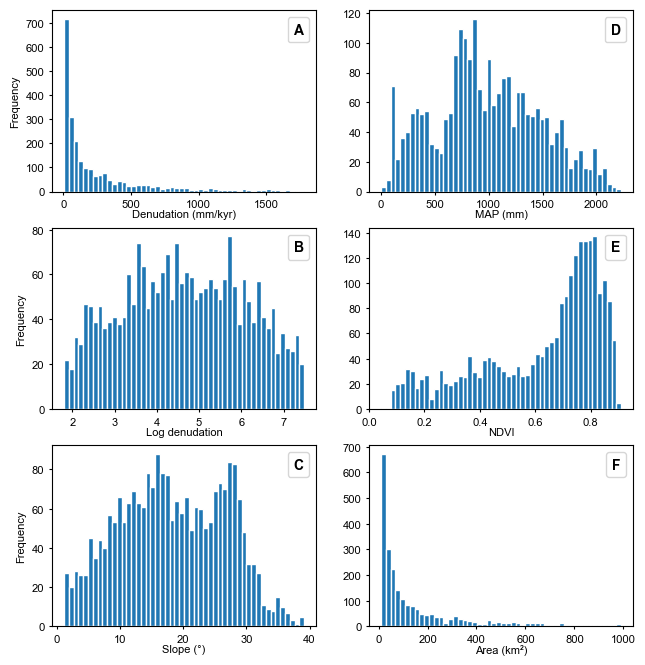

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(7.5,8), dpi=100, facecolor='white')

ax[0,0].hist(data0['EBE_MMKYR'], bins=50, edgecolor='white', label='A')
ax[0,0].set_xlabel('Denudation (mm/kyr)', labelpad=0)
ax[0,0].set_ylabel('Frequency')
ax[0,0].tick_params(axis='both', length=2)
ax[0,0].legend(handlelength=0, handletextpad=0.03, prop={'weight': 'bold', 'size': 10, 'family': 'Arial'})

data0['log_EBE_MMKYR'] = data0['EBE_MMKYR'].apply(math.log)
ax[1,0].hist(data0['log_EBE_MMKYR'], bins=50, edgecolor='white', label='B')
ax[1,0].set_xlabel('Log denudation', labelpad=0)
ax[1,0].set_ylabel('Frequency')
ax[1,0].tick_params(axis='both', length=2)
ax[1,0].legend(handlelength=0, handletextpad=0.03, prop={'weight': 'bold', 'size': 10, 'family': 'Arial'})

ax[2,0].hist(data0['SLP_deg'], bins=50, edgecolor='white', label='C')
ax[2,0].set_xlabel('Slope (°)', labelpad=0)
ax[2,0].set_ylabel('Frequency')
ax[2,0].tick_params(axis='both', length=2)
ax[2,0].legend(handlelength=0, handletextpad=0.03, prop={'weight': 'bold', 'size': 10, 'family': 'Arial'})

ax[0,1].hist(data0['MAP'], bins=50, edgecolor='white', label='D')
ax[0,1].set_xlabel('MAP (mm)', labelpad=0)
# ax[0,1].set_ylabel('Frequency')
ax[0,1].tick_params(axis='both', length=2)
ax[0,1].legend(handlelength=0, handletextpad=0.03, prop={'weight': 'bold', 'size': 10, 'family': 'Arial'})

ax[1,1].hist(data0['NDVI'], bins=50, edgecolor='white', label='E')
ax[1,1].set_xlabel('NDVI', labelpad=0)
# ax[1,1].set_ylabel('Frequency')
ax[1,1].tick_params(axis='both', length=2)
ax[1,1].legend(handlelength=0, handletextpad=0.03, prop={'weight': 'bold', 'size': 10, 'family': 'Arial'})

ax[2,1].hist(data0['AREA'], bins=50, edgecolor='white', label='F')
ax[2,1].set_xlabel('Area (km²)', labelpad=0)
# ax[2,1].set_ylabel('Frequency')
ax[2,1].tick_params(axis='both', length=2)
ax[2,1].legend(handlelength=0, handletextpad=0.03, prop={'weight': 'bold', 'size': 10, 'family': 'Arial'})

# plt.savefig("Results/260309/Figure 2.svg", dpi=100, bbox_inches='tight')